Working...:   0%|                                                                               | 0/14 [00:00<?, ?it/s]

image_inventory_cam_1002.xlsx:Label_2
image_inventory_cam_1002.xlsx:Label_3
image_inventory_cam_1005.xlsx:Label_2
image_inventory_cam_1005.xlsx:Label_3


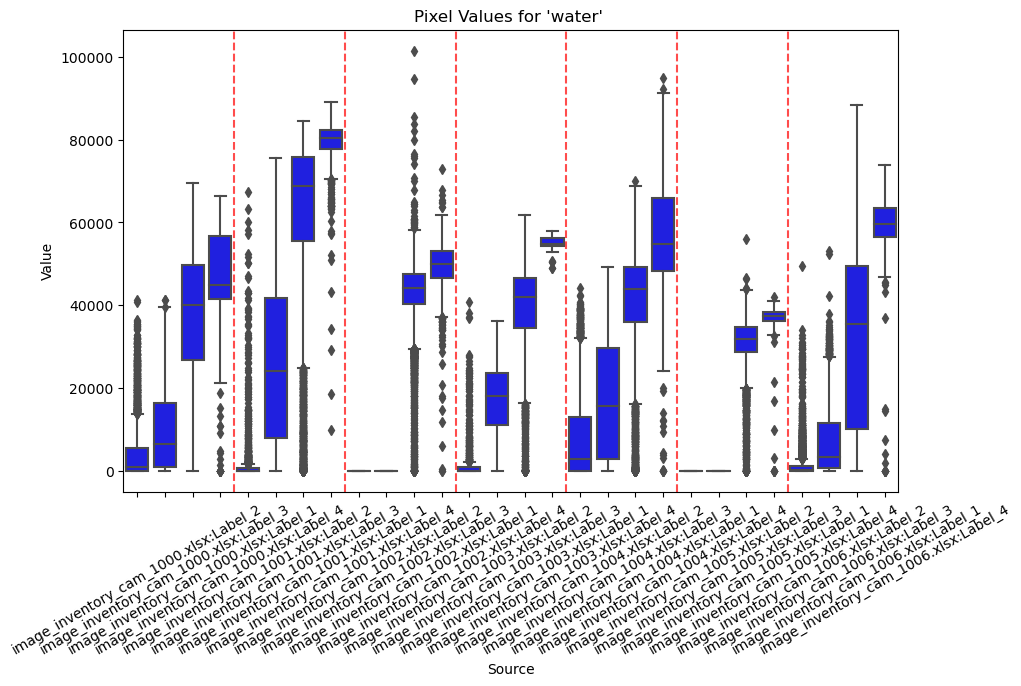

Working...:   7%|█████                                                                  | 1/14 [00:44<09:38, 44.47s/it]

image_inventory_cam_1002.xlsx:Label_2
image_inventory_cam_1002.xlsx:Label_3
image_inventory_cam_1005.xlsx:Label_2
image_inventory_cam_1005.xlsx:Label_3


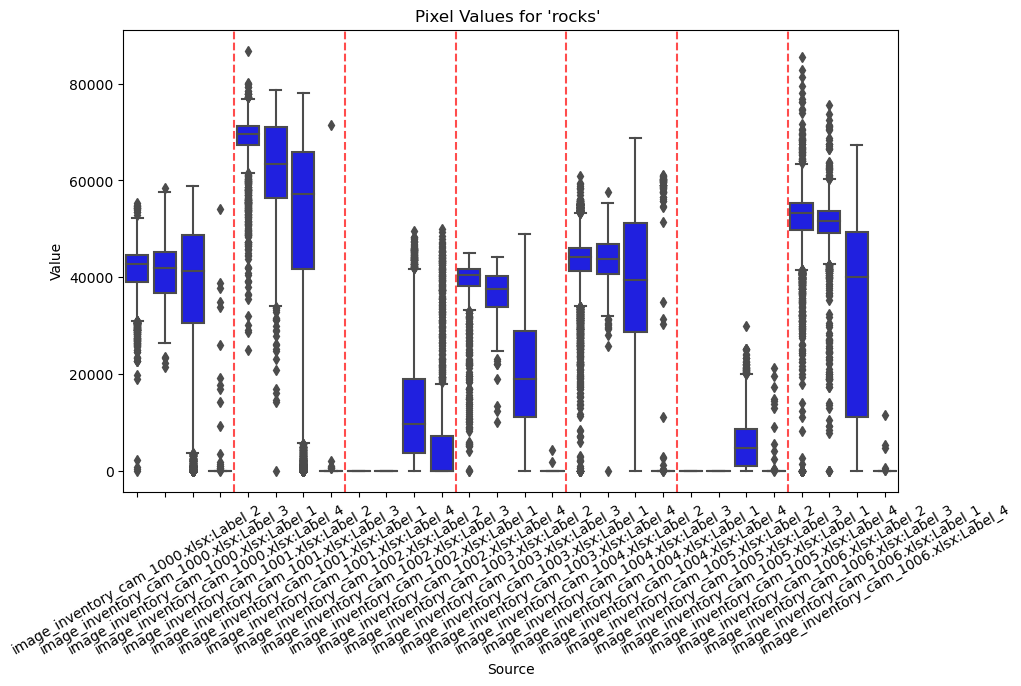

Working...:  14%|██████████▏                                                            | 2/14 [01:29<08:58, 44.87s/it]

image_inventory_cam_1002.xlsx:Label_2
image_inventory_cam_1002.xlsx:Label_3
image_inventory_cam_1005.xlsx:Label_2
image_inventory_cam_1005.xlsx:Label_3


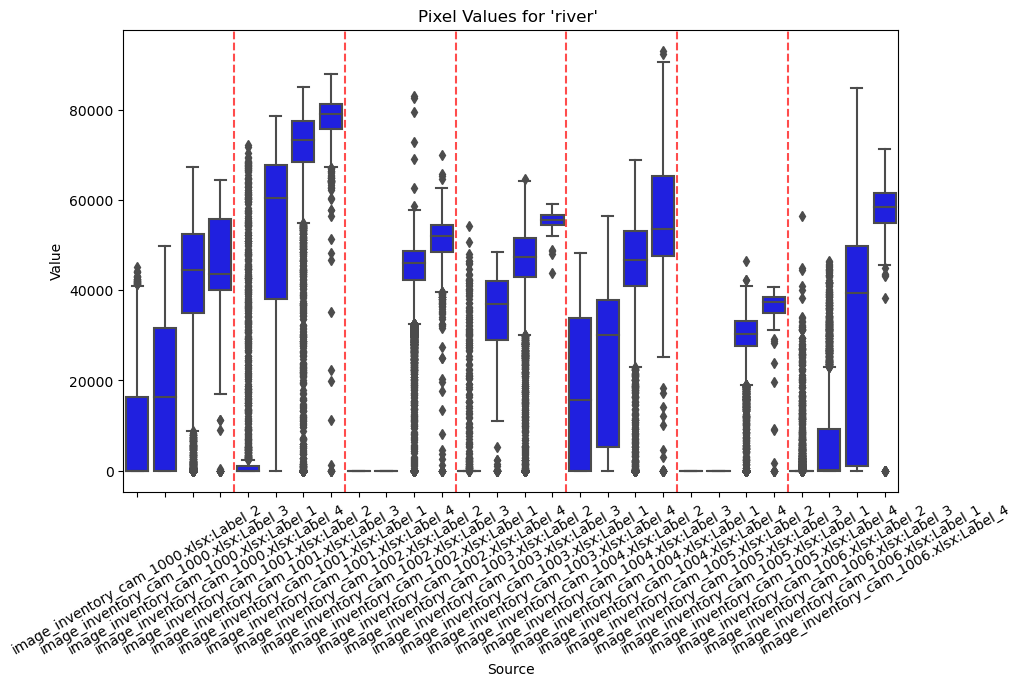

Working...:  21%|███████████████▏                                                       | 3/14 [02:15<08:17, 45.22s/it]

image_inventory_cam_1002.xlsx:Label_2
image_inventory_cam_1002.xlsx:Label_3
image_inventory_cam_1005.xlsx:Label_2
image_inventory_cam_1005.xlsx:Label_3


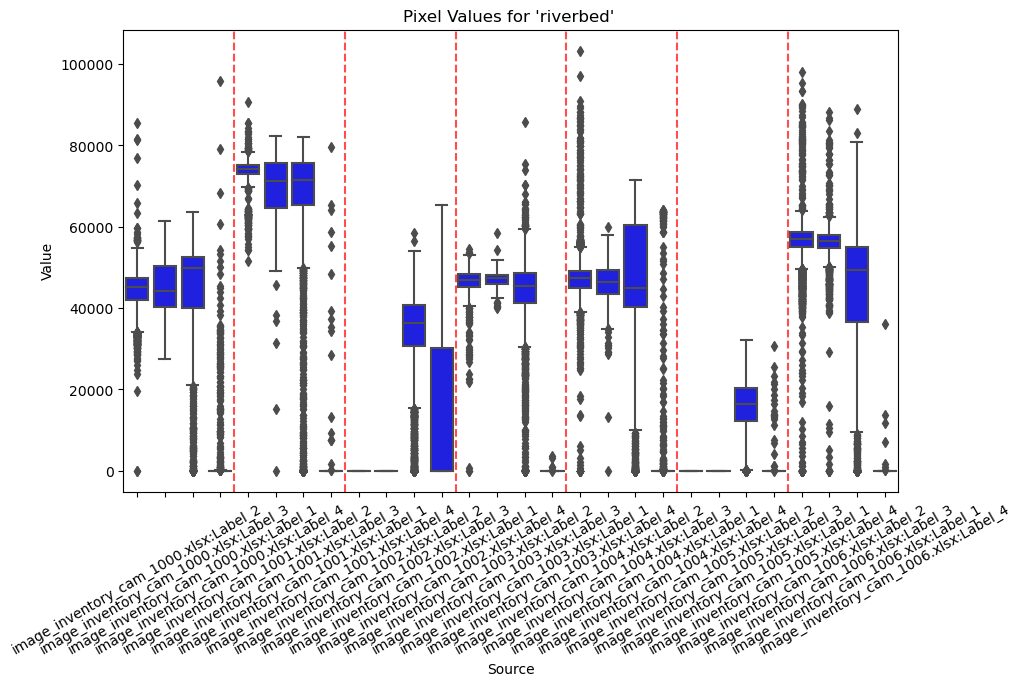

Working...:  29%|████████████████████▎                                                  | 4/14 [02:59<07:28, 44.89s/it]

image_inventory_cam_1002.xlsx:Label_2
image_inventory_cam_1002.xlsx:Label_3
image_inventory_cam_1005.xlsx:Label_2
image_inventory_cam_1005.xlsx:Label_3


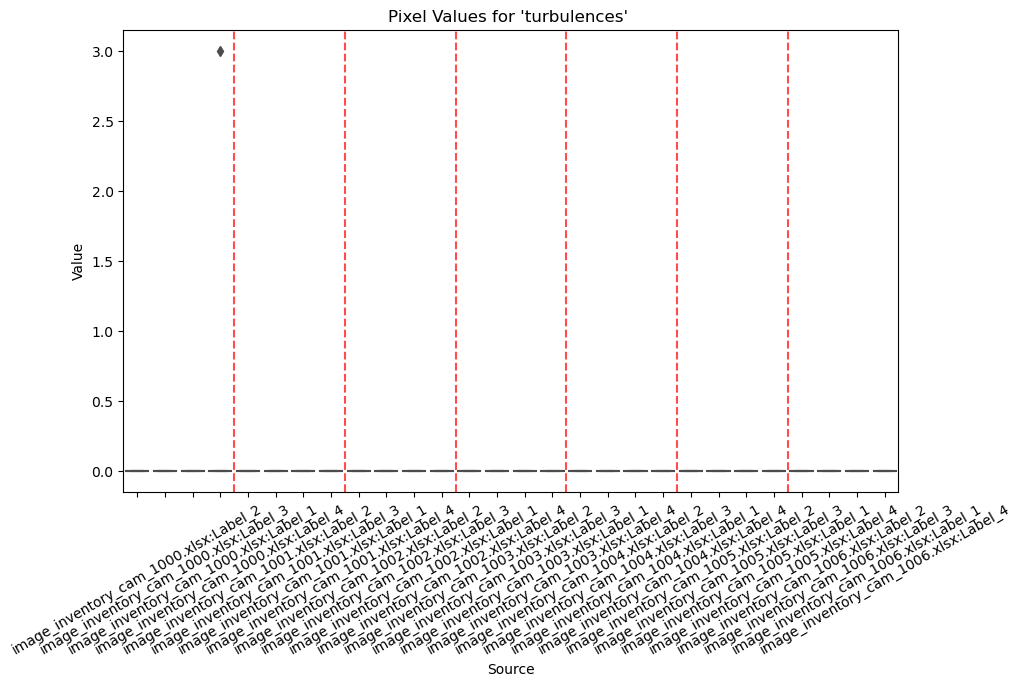

Working...:  36%|█████████████████████████▎                                             | 5/14 [03:43<06:41, 44.57s/it]

image_inventory_cam_1002.xlsx:Label_2
image_inventory_cam_1002.xlsx:Label_3
image_inventory_cam_1005.xlsx:Label_2
image_inventory_cam_1005.xlsx:Label_3


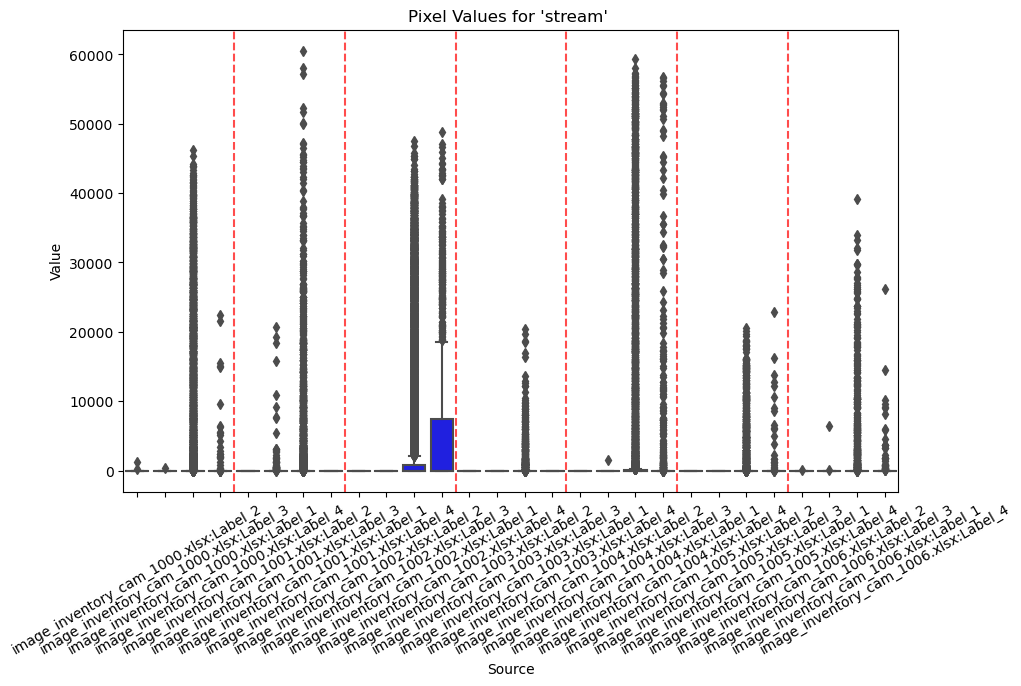

Working...:  43%|██████████████████████████████▍                                        | 6/14 [04:28<05:56, 44.52s/it]

image_inventory_cam_1002.xlsx:Label_2
image_inventory_cam_1002.xlsx:Label_3
image_inventory_cam_1005.xlsx:Label_2
image_inventory_cam_1005.xlsx:Label_3


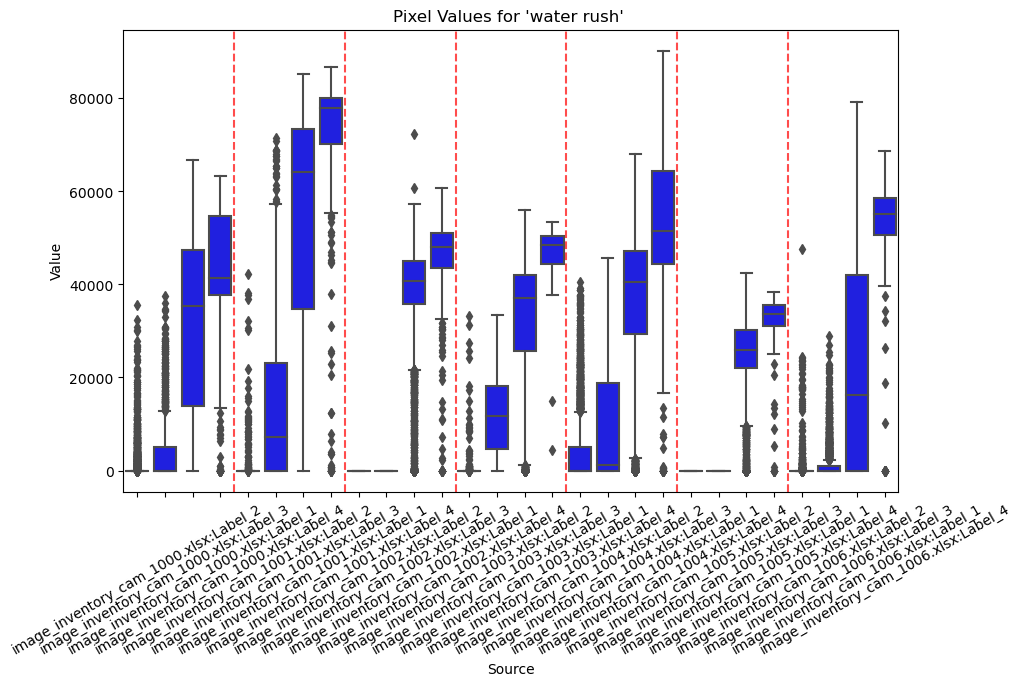

Working...:  50%|███████████████████████████████████▌                                   | 7/14 [05:12<05:11, 44.43s/it]

image_inventory_cam_1002.xlsx:Label_2
image_inventory_cam_1002.xlsx:Label_3
image_inventory_cam_1005.xlsx:Label_2
image_inventory_cam_1005.xlsx:Label_3


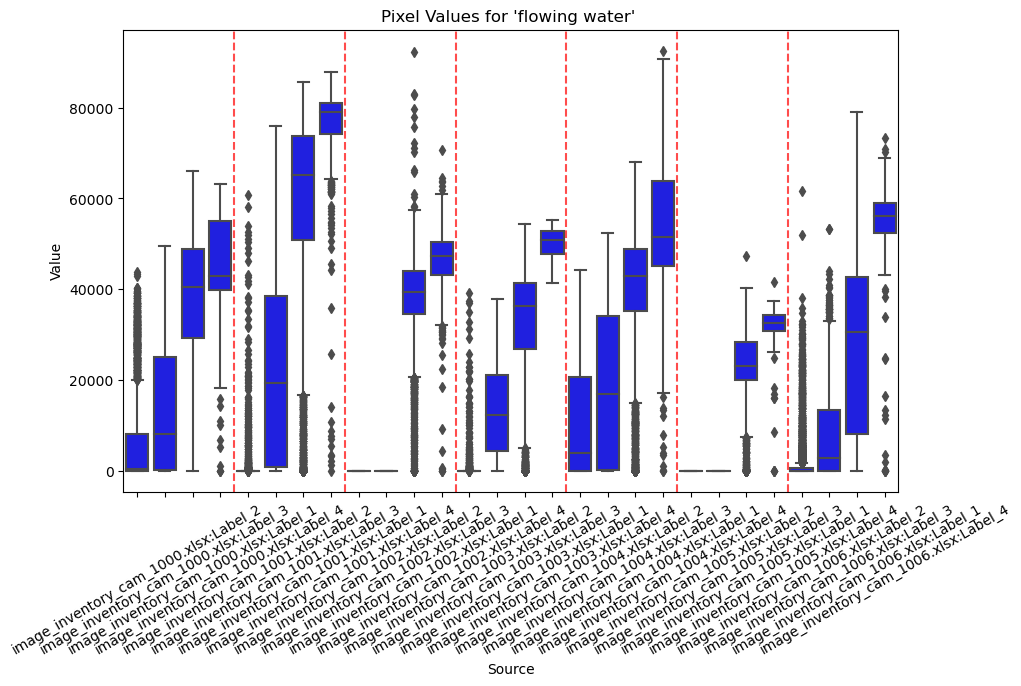

Working...:  57%|████████████████████████████████████████▌                              | 8/14 [05:56<04:26, 44.37s/it]

image_inventory_cam_1002.xlsx:Label_2
image_inventory_cam_1002.xlsx:Label_3
image_inventory_cam_1005.xlsx:Label_2
image_inventory_cam_1005.xlsx:Label_3


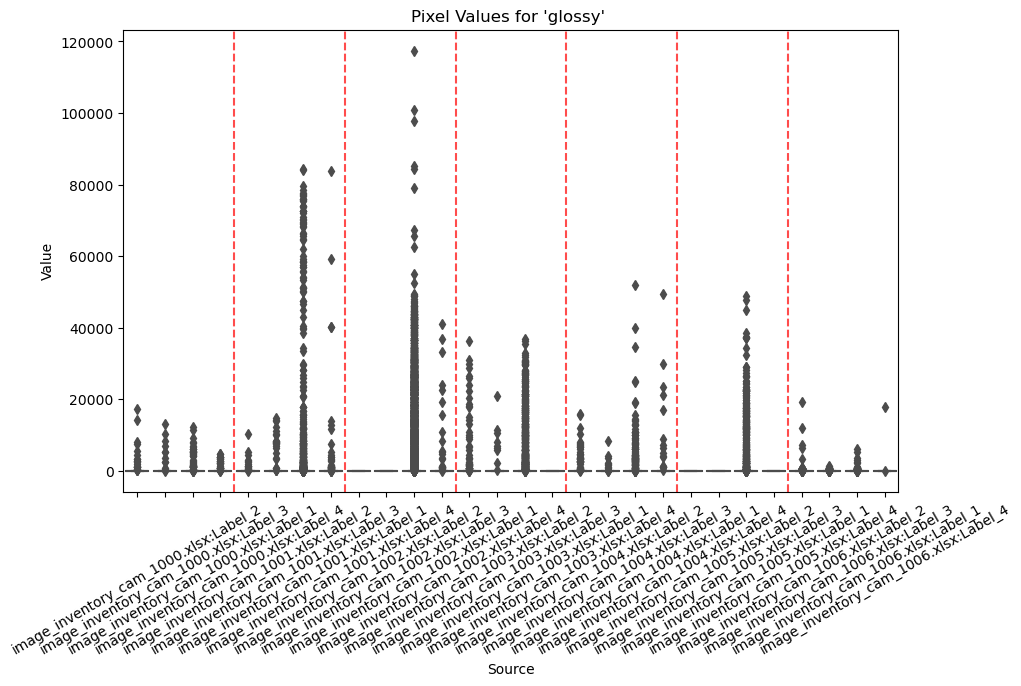

Working...:  64%|█████████████████████████████████████████████▋                         | 9/14 [06:41<03:42, 44.52s/it]

image_inventory_cam_1002.xlsx:Label_2
image_inventory_cam_1002.xlsx:Label_3
image_inventory_cam_1005.xlsx:Label_2
image_inventory_cam_1005.xlsx:Label_3


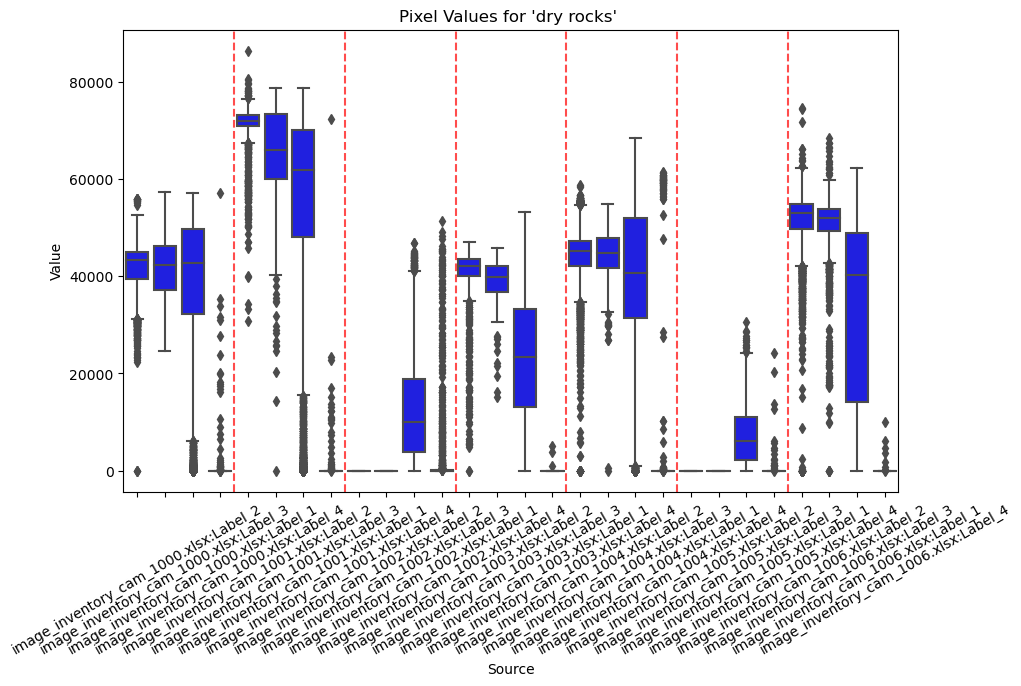

Working...:  71%|██████████████████████████████████████████████████                    | 10/14 [07:25<02:58, 44.53s/it]

image_inventory_cam_1002.xlsx:Label_2
image_inventory_cam_1002.xlsx:Label_3
image_inventory_cam_1005.xlsx:Label_2
image_inventory_cam_1005.xlsx:Label_3


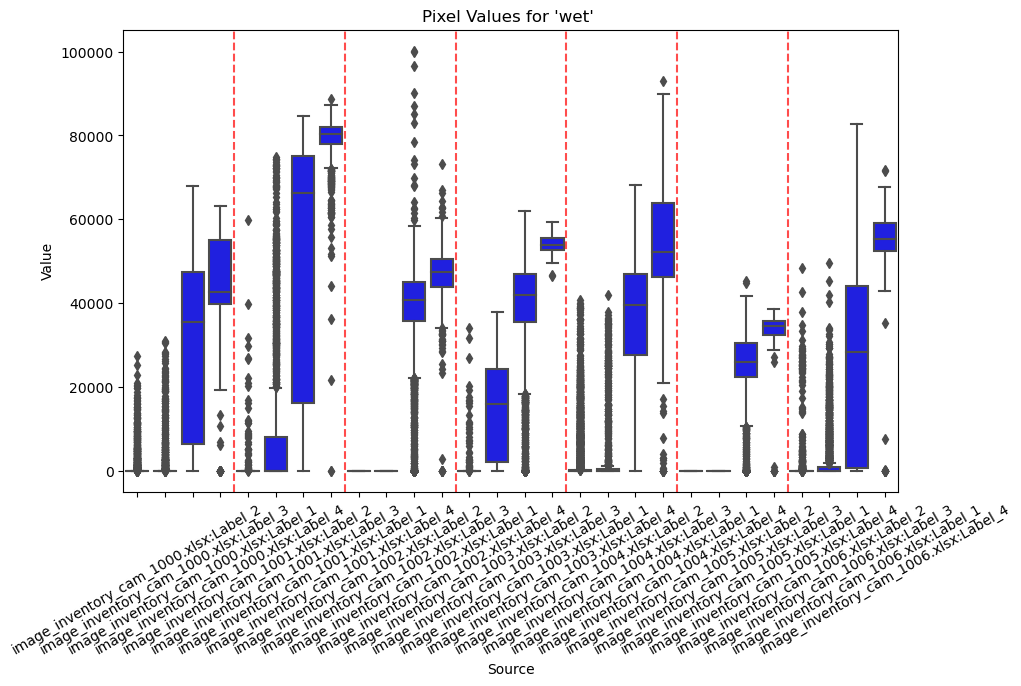

Working...:  79%|███████████████████████████████████████████████████████               | 11/14 [08:10<02:13, 44.50s/it]

image_inventory_cam_1002.xlsx:Label_2
image_inventory_cam_1002.xlsx:Label_3
image_inventory_cam_1005.xlsx:Label_2
image_inventory_cam_1005.xlsx:Label_3


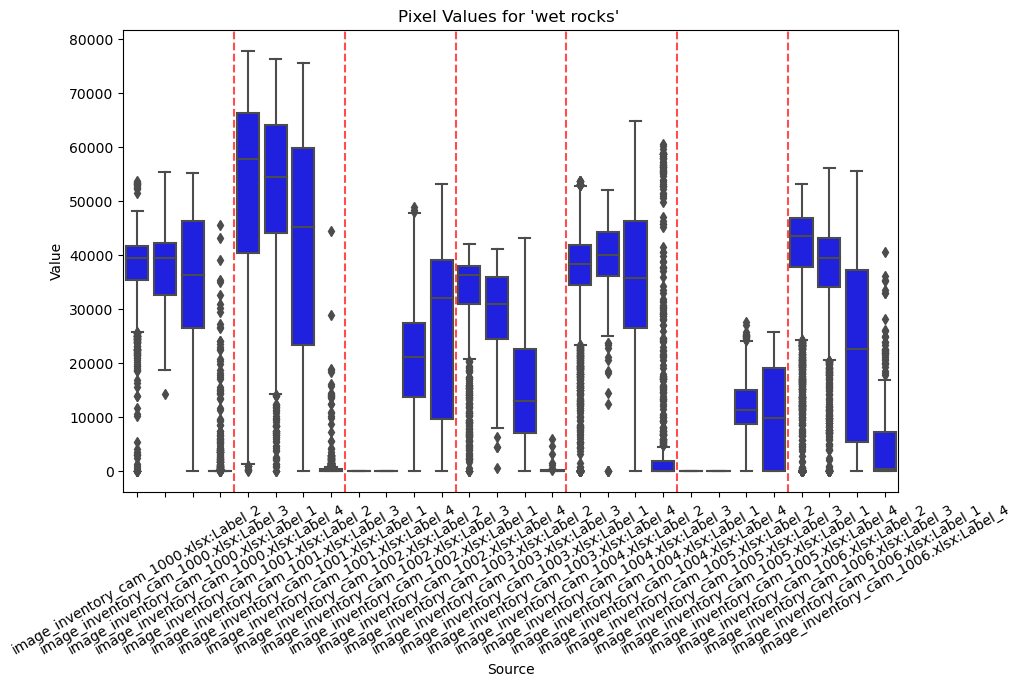

Working...:  86%|████████████████████████████████████████████████████████████          | 12/14 [08:54<01:28, 44.46s/it]

image_inventory_cam_1002.xlsx:Label_2
image_inventory_cam_1002.xlsx:Label_3
image_inventory_cam_1005.xlsx:Label_2
image_inventory_cam_1005.xlsx:Label_3


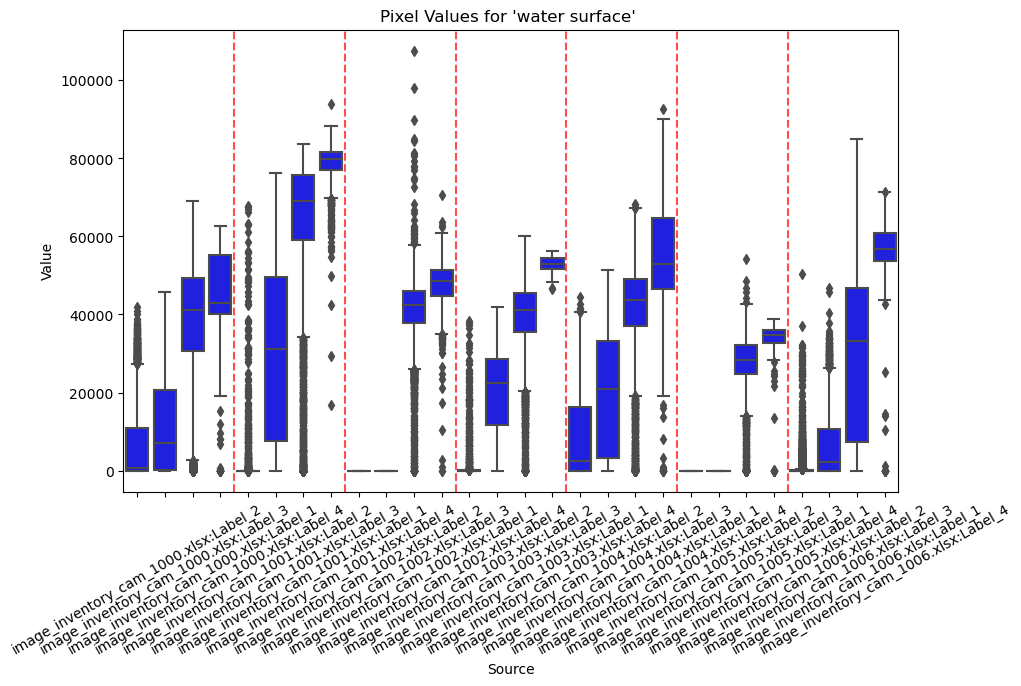

Working...:  93%|█████████████████████████████████████████████████████████████████     | 13/14 [09:39<00:44, 44.45s/it]

image_inventory_cam_1002.xlsx:Label_2
image_inventory_cam_1002.xlsx:Label_3
image_inventory_cam_1005.xlsx:Label_2
image_inventory_cam_1005.xlsx:Label_3


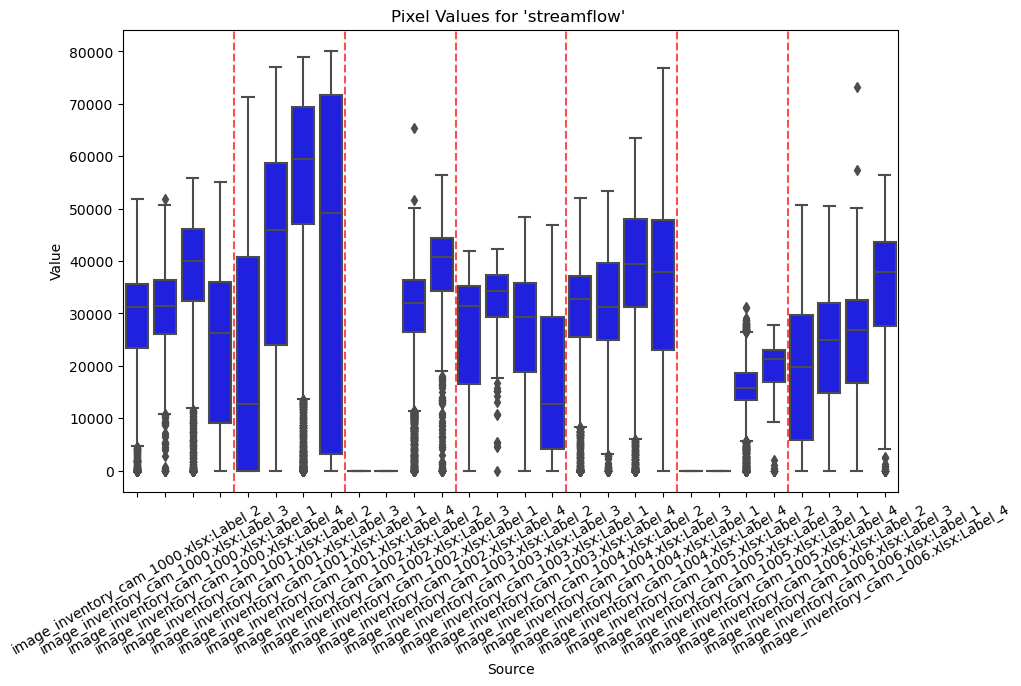

Working...: 100%|██████████████████████████████████████████████████████████████████████| 14/14 [10:23<00:00, 44.52s/it]


In [14]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm

file_paths = [
    'image_inventory_cam_1000.xlsx',   
    'image_inventory_cam_1001.xlsx',
    'image_inventory_cam_1002.xlsx',
    'image_inventory_cam_1003.xlsx',
    'image_inventory_cam_1004.xlsx',
    'image_inventory_cam_1005.xlsx',
    'image_inventory_cam_1006.xlsx',
]
sheet_names = [
    'Label_2',
    'Label_3',
    'Label_1',
    'Label_4',
]
prompts = [
    'water',
    'rocks',	
    'river',
    'riverbed',
    'turbulences',
    'stream',
    'water rush',
    'flowing water',
    'glossy',
    'dry rocks',
    'wet',
    'wet rocks',
    'water surface',
    'streamflow',
]

for prompt in tqdm(prompts, desc='Working...'):
    data = []
    for file_path in file_paths:
        for sheet_name in sheet_names:
            df = pd.read_excel(file_path, sheet_name=sheet_name)  # no headers
            try:
                values = df[prompt].dropna().values  # pick that column
                for v in values:
                    data.append({"Source": f"{file_path}:{sheet_name}", "Value": v})
            except:
                print(f"{file_path}:{sheet_name}")
                data.append({"Source": f"{file_path}:{sheet_name}", "Value": 0})

    df_long = pd.DataFrame(data)

    # === PLOT MULTIBOXPLOT ===
    plt.figure(figsize=(10,6))
    ax = sns.boxplot(x="Source", y="Value", data=df_long, color='blue')
    plt.title(f"Pixel Values for '{prompt}' ")
    plt.xticks(rotation=30)

    num_categories = len(df_long["Source"].unique())
    for i in range(4, num_categories, 4):
        ax.axvline(i - 0.5, color="red", linestyle="--", alpha=0.7)

    plt.savefig(f"boxplot_{prompt}.png", dpi=300, bbox_inches="tight")  # save as PNG
    plt.show()

# print out one specific column ### make sure header correct
# boxplot it
# for loop it